## CalculateEmbeddings

This script:
- Loads list of sample points, each with 4 associated image files from an H5 data store
- Calculates an image embedding for each image file
- Saves the embeddings with the other metadata in the H5 store.

### Dependencies
**Prerequisites:** Script 1 (creates the H5 store with images).

**Inputs:**
- `street_data.h5` (via `h5_filename`) — reads `point_id`, `images_jpeg`, `images_present`

**Outputs:**
- Updates `street_data.h5` in-place, adding `embeddings_clip` dataset (N × 4 × 512, float32)

**Used by:** Script 3

In [1]:
import io
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm
import clip
import h5py
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt

/opt/homebrew/anaconda3/envs/streetview-deprivation-amsterdam/lib/python3.14/site-packages/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [2]:
from directory_filepaths import *

print("Directory paths are:")
print("data_dir: ", data_dir)
print("boundaries_file: ", boundaries_file)
print("ses_file: ", ses_file)
print("h5_filename: ", h5_filename)

Directory paths are:
data_dir:  ../data/processed
boundaries_file:  ../data/raw/spatial/buurten_2024/amsterdam_buurten_2024.gpkg
ses_file:  ../data/processed/ses_woa_86092NED.csv
h5_filename:  ../data/processed/street_data.h5


### Load list of sample points

This contains points sampled along the road network in 1-SampleStreetNetwork.ipynb  

Each point has an ID, a latitude, a longitude, and 4 image files associated with it (these are sampled in each of the 4 cardinal directions from the sample point)  

This script will also create an 'embeddings' slot that it will fill with a list of embeddings for each of the 4 images

In [3]:
with h5py.File(h5_filename, "r") as f:
    print(f"H5 file contains {len(f["point_id"])} items")
    print("Keys are: ", list(f.keys()))

#points_data_cache = data_dir + "sample_points_cache/points_data_cache.pkl"
#with open(points_data_cache, "rb") as f:
#        point_records = pickle.load(f)
#print(f"Cache currently has {len(point_records)} points.")

H5 file contains 50048 items
Keys are:  ['date', 'embeddings_clip', 'image_paths', 'images_jpeg', 'images_present', 'latitude', 'longitude', 'mission_year', 'pano_id', 'point_id']


# Compute the Embeddings

In [4]:
# Define model and device to run it

def get_device():
    if torch.backends.mps.is_available():  # macs
        return torch.device("mps")
    elif torch.cuda.is_available():  # for completeness if you ever run on CUDA
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print("Using device:", device)
model, preprocess = clip.load("ViT-B/32", device=device)

Using device: mps


## Create embedding for each image and find similarity to categories 
- Create embedding for image
- Find similarity score to text embedding for each category
- Convert similarity score to a "probability-like number" using softmax

Prepare the database (we need an embeddings column)

In [5]:
dim = 512  # Length of CLIP embeddings
overwrite_embeddings = False  # Set to True to recalculate and overwrite existing embeddings
calculate_embeddings = True  # Will be set to False if we skip (i.e. if embeddins have already been calculated)

with h5py.File(h5_filename, "a") as f:
    N = f["point_id"].shape[0]

    if "embeddings_clip" in f:
        if not overwrite_embeddings:
            existing = f["embeddings_clip"][:]
            n_populated = np.count_nonzero(~np.all(np.isnan(existing), axis=-1)) // 4
            print(f"embeddings_clip already exists with {n_populated}/{N} points populated.")
            print("Skipping. Set overwrite_embeddings = True to recalculate.")
            calculate_embeddings = False
        else:
            print("overwrite_embeddings is True, replacing existing embeddings.")
            del f["embeddings_clip"]
            f.create_dataset(
                "embeddings_clip",
                shape=(N, 4, dim),
                dtype="float32",
                fillvalue=np.nan
            )
            print(f"Created embeddings_clip dataset with shape ({N}, 4, {dim})")
    else:
        f.create_dataset(
            "embeddings_clip",
            shape=(N, 4, dim),
            dtype="float32",
            fillvalue=np.nan
        )
        print(f"Created embeddings_clip dataset with shape ({N}, 4, {dim})")

embeddings_clip already exists with 50048/50048 points populated.
Skipping. Set overwrite_embeddings = True to recalculate.


Calculate the embeddings (unless they have already been calculated)

In [6]:
def load_pil_from_h5(f, row_idx, slot):
    """
    Returns a PIL.Image for the given row and slot, reading 'images_jpeg' bytes.
    Raises FileNotFoundError if images_present is False.
    """
    if not bool(f["images_present"][row_idx, slot]):
        raise FileNotFoundError(f"No image stored at row {row_idx}, slot {slot}")

    jpeg_bytes = f["images_jpeg"][row_idx, slot].tobytes()
    return Image.open(io.BytesIO(jpeg_bytes)).convert("RGB")


def embed_clip_pil(pil_image):
    """
    Compute a CLIP embedding from a PIL image.
    Returns a (D,) float32 numpy array (unit-normalized).
    """
    image_tensor = preprocess(pil_image).unsqueeze(0).to(device)

    with torch.no_grad():
        raw = model.encode_image(image_tensor)
        emb = raw / raw.norm(dim=-1, keepdim=True)

    return emb.squeeze(0).detach().cpu().numpy().astype("float32")


if not calculate_embeddings:
    print("Skipping embedding calculation (embeddings already exist).")
else:
    with h5py.File(h5_filename, "a") as f:
        if "embeddings_clip" not in f:
            raise KeyError("No embeddings file, this should have been created above.")

        emb_ds = f["embeddings_clip"]    # shape: (N, 4, D)
        N, _, D = emb_ds.shape
        print(f"Embeddings shape: {emb_ds.shape}")

        for i in tqdm(range(N), desc="Embedding CLIP from HDF5", unit="point"):
            for j in range(4):
                try:
                    # Decode image from HDF5
                    pil_img = load_pil_from_h5(f, i, j)

                    # Compute embedding and write it
                    emb = embed_clip_pil(pil_img)  # (D,)
                    if emb.shape[0] != D:
                        raise ValueError(f"Embedding dim mismatch: got {emb.shape[0]}, expected {D}")
                    emb_ds[i, j, :] = emb
                except FileNotFoundError:
                    # Missing image -> leave NaNs
                    tqdm.write(f"Missing image at {i}, {j}, not calculating the embedding")
                    emb_ds[i, j, :] = np.nan
                except Exception as e:
                    # Any other error -> write NaNs to mark as missing/bad
                    emb_ds[i, j, :] = np.nan
                    tqdm.write(f"Error at row {i}, slot {j}: {e}")

    print("Finished")

Skipping embedding calculation (embeddings already exist).


Done!

To finish just print a bit of information about what's in the H5 data store

In [7]:
with h5py.File(h5_filename, "r") as f:
    print(f"H5 data store: {h5_filename}")
    print(f"{'Dataset':<20} {'Shape':<25} {'Dtype'}")
    print("-" * 60)
    for key in sorted(f.keys()):
        ds = f[key]
        print(f"{key:<20} {str(ds.shape):<25} {ds.dtype}")

    N = f["point_id"].shape[0]
    n_images = np.count_nonzero(f["images_present"][:])
    print(f"\nTotal points: {N}")
    print(f"Images present: {n_images} / {N * 4}")

    if "embeddings_clip" in f:
        emb = f["embeddings_clip"][:]
        n_emb = np.count_nonzero(~np.all(np.isnan(emb), axis=-1))
        print(f"Embeddings populated: {n_emb} / {N * 4}")

H5 data store: ../data/processed/street_data.h5
Dataset              Shape                     Dtype
------------------------------------------------------------
date                 (50048,)                  |S10
embeddings_clip      (50048, 4, 512)           float32
image_paths          (50048, 4)                |S512
images_jpeg          (50048, 4)                object
images_present       (50048, 4)                bool
latitude             (50048,)                  float64
longitude            (50048,)                  float64
mission_year         (50048,)                  int32
pano_id              (50048,)                  |S64
point_id             (50048,)                  int32

Total points: 50048
Images present: 200192 / 200192
Embeddings populated: 200192 / 200192


## Sanity-check map — embeddings as RGB

A quick visual check that the embeddings are *broadly sensible*. We reduce the 512-d CLIP embeddings to
**three principal components with PCA** and use them directly as **R, G, B**, so each point is coloured
by what its imagery "looks like" to CLIP. We are not after any particular meaning for each axis — the
test is **spatial coherence**: visually similar streetscapes should get similar colours, so neighbouring
points should vary smoothly (parks, water frontage, dense centre, post-war estates forming recognisable
patches) rather than looking like random noise. Salt-and-pepper colour would suggest something is wrong
upstream.

The PCA→RGB model is fit here and **cached to disk** (`embedding_rgb_pca_file`, via `embedding_rgb.py`).
It is **re-fit every time this notebook runs**, because new imagery/embeddings may have been added. Later
steps that want the *same* colours should `load_embedding_rgb(...)` rather than re-fitting.

In [8]:
from embedding_rgb import fit_embedding_rgb, embeddings_to_rgb

# Load the embeddings and coordinates from the H5 store
with h5py.File(h5_filename, "r") as f:
    emb = f["embeddings_clip"][:]      # (N, 4, 512)
    lat = f["latitude"][:]
    lon = f["longitude"][:]
N = emb.shape[0]

# Fit the PCA->RGB model on every per-crop embedding (the richest, most numerous
# sample) and CACHE it, so the identical colour model can be reused later in the
# pipeline. Re-fit each run: new imagery/embeddings may have been added.
model = fit_embedding_rgb(emb, cache_path=embedding_rgb_pca_file)

# One embedding per point = mean over its available cardinal crops (ignoring NaNs)
with np.errstate(invalid="ignore"):
    point_emb = np.nanmean(emb, axis=1)            # (N, 512); NaN if a point has no crops

# Colour each point by its aggregated embedding through the same cached model
rgb = embeddings_to_rgb(model, point_emb)          # (N, 3) in [0, 1], NaN rows for empty points

evr = model["explained_variance_ratio"]
print(f"Fitted PCA->RGB model on {model['n_fit']} crop embeddings; cached to {embedding_rgb_pca_file}")
print(f"Explained variance  R: {evr[0]:.1%}  G: {evr[1]:.1%}  B: {evr[2]:.1%}  (total {evr.sum():.1%})")
print(f"Points coloured     : {int(np.isfinite(rgb).all(axis=1).sum())} / {N}")

Fitted PCA->RGB model on 200192 crop embeddings; cached to ../data/processed/embedding_rgb_pca.joblib
Explained variance  R: 13.6%  G: 8.2%  B: 5.7%  (total 27.4%)
Points coloured     : 50048 / 50048


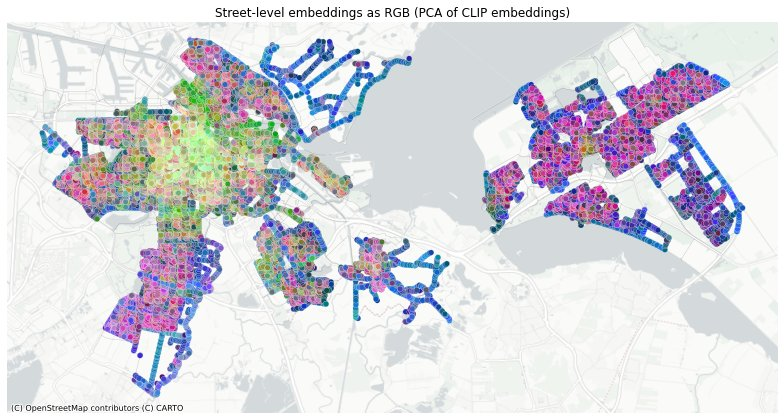

In [9]:
# Build a GeoDataFrame of the coloured points and reproject to Web Mercator (the
# CRS of the contextily basemap tiles).
keep = np.isfinite(rgb).all(axis=1)
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lon[keep], lat[keep]),
    crs=GEOGRAPHIC_CRS,
).to_crs(epsg=3857)
colours = rgb[keep]

fig, ax = plt.subplots(figsize=(11, 11))

# Faint buurt outlines for orientation (skipped gracefully if the file is absent)
try:
    buurten = gpd.read_file(boundaries_file).to_crs(epsg=3857)
    buurten.boundary.plot(ax=ax, color="#000000", linewidth=0.3, alpha=0.15, zorder=2)
except Exception as e:
    print(f"[buurt outlines skipped: {e}]")

ax.scatter(gdf.geometry.x, gdf.geometry.y, c=colours, s=30,
           edgecolors="white", linewidths=0.2, zorder=3)

# Fit the view to the points (with a small margin), so the map zooms to where the
# data is rather than to the whole municipality — useful for partial/dev samples.
xmin, ymin, xmax, ymax = gdf.total_bounds
mx = max((xmax - xmin) * 0.05, 200)
my = max((ymax - ymin) * 0.05, 200)
ax.set_xlim(xmin - mx, xmax + mx)
ax.set_ylim(ymin - my, ymax + my)

# Non-interactive basemap backdrop (like the maps in notebook 1)
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs="EPSG:3857", zorder=1)

ax.set_axis_off()
ax.set_title("Street-level embeddings as RGB (PCA of CLIP embeddings)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join("../", "outputs", "2-embeddings-points-map.png"), dpi=128)
show_jpeg()